Projeto - Análise no dataset alvo - Proteina 6B1T - https://www.rcsb.org/structure/6B1T

In [1]:
!pip install biopython pandas networkx numpy matplotlib seaborn infomap scipy

In [2]:
from Bio.PDB import PDBParser
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import cKDTree
from matplotlib.patches import Patch
from networkx.algorithms.community import louvain_communities, modularity
from infomap import Infomap

Um arquivo PDB possui:
Estrutura
 └── Modelo
      └── Cadeia
           └── Resíduo
                └── Átomo

In [3]:
def extrair_residuos_pdb(arquivo_pdb):
    parser = PDBParser(QUIET=True)
    nome = arquivo_pdb.split("/")[-1]
    estrutura = parser.get_structure(nome,arquivo_pdb)
    dados = []
    for modelo in estrutura:
        for cadeia in modelo:
            for residuo in cadeia:
                if residuo.id[0] != " ":
                    continue
                if "CA" not in residuo:
                    print(f"Residuo {residuo.id} da cadeia {cadeia.id} não possui átomo CA. Pulando...")
                    continue
                ca = residuo["CA"]
                x, y, z = ca.coord
                dados.append({
                    "arquivo": nome,
                    "cadeia": cadeia.id,
                    "residuo_id": residuo.id[1],
                    "residuo_nome": residuo.resname,
                    "x": x,
                    "y": y,
                    "z": z
                })
    return pd.DataFrame(dados)

In [4]:
nome_proteina = "6B1T"
df1 = extrair_residuos_pdb("data/raw/6B1T/6b1t-pdb-bundle1.pdb")
df2 = extrair_residuos_pdb("data/raw/6B1T/6b1t-pdb-bundle2.pdb")
df_residuos = pd.concat([df1, df2], ignore_index=True)

df_residuos["node_id"] = (
    df_residuos["cadeia"].astype(str)
    + "_"
    + df_residuos["residuo_id"].astype(str)
)

print(df_residuos.head())
print(df_residuos.shape)
df_residuos.groupby("cadeia").size()
print("Linhas:", len(df_residuos))
print("Node IDs:", df_residuos["node_id"].nunique())

                arquivo cadeia  residuo_id residuo_nome          x  \
0  6b1t-pdb-bundle1.pdb      A           6          MET  35.067001   
1  6b1t-pdb-bundle1.pdb      A           7          MET  32.890999   
2  6b1t-pdb-bundle1.pdb      A           8          PRO  29.086000   
3  6b1t-pdb-bundle1.pdb      A           9          GLN  28.686001   
4  6b1t-pdb-bundle1.pdb      A          10          TRP  31.304001   

            y           z node_id  
0  140.119003  314.084015     A_6  
1  138.360001  316.661987     A_7  
2  138.692993  316.332001     A_8  
3  139.419006  320.045013     A_9  
4  142.171997  320.027008    A_10  
(12544, 8)
Linhas: 12544
Node IDs: 12544


In [5]:
def construir_grafo_kdtree(
    df_residuos,
    limiar,
    mesma_cadeia=False
):

    G = nx.Graph()

    node_ids = df_residuos["node_id"].values
    cadeias = df_residuos["cadeia"].values

    coords = df_residuos[["x","y","z"]].values

    for _, linha in df_residuos.iterrows():

        G.add_node(
            linha["node_id"],
            cadeia=linha["cadeia"],
            residuo=linha["residuo_nome"],
            residuo_id=linha["residuo_id"],
            x=linha["x"],
            y=linha["y"],
            z=linha["z"]
        )

    tree = cKDTree(coords)

    pares = tree.query_pairs(r=limiar)

    for i, j in pares:

        if mesma_cadeia:

            if cadeias[i] != cadeias[j]:
                continue

        dist = np.linalg.norm(coords[i] - coords[j]) 

        G.add_edge(
            node_ids[i],
            node_ids[j],
            distancia=dist,
            weight=1/(dist + 1e-6)
        )

    G.graph["limiar"] = limiar
    G.graph["mesma_cadeia"] = mesma_cadeia

    return G

In [6]:
# Distância máxima para considerar uma interação (Angstroms)
limiar = 8.0
G = construir_grafo_kdtree(df_residuos, limiar)

In [7]:
# Impressão das estatísticas globais
print("="*60)
print("Estatísticas globais da rede")
print(f"Nós: {G.number_of_nodes()}")
print(f"Arestas: {G.number_of_edges()}")
print(f"Conectividade: {nx.is_connected(G)}")
print(f"Densidade: {nx.density(G):.4f}")
if nx.is_connected(G):
    print(f"Comprimento médio dos caminhos mais curtos: {nx.average_shortest_path_length(G):.2f}")
    print(f"Diâmetro: {nx.diameter(G)}")
print("="*60)


Estatísticas globais da rede
Nós: 12544
Arestas: 66809
Conectividade: True
Densidade: 0.0008
Comprimento médio dos caminhos mais curtos: 19.83
Diâmetro: 58


In [24]:
# Dados dos nós
graus = dict(G.degree())
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G)
#eigenvector = nx.eigenvector_centrality(G)
eigenvector = nx.eigenvector_centrality_numpy(G)
page_rank = nx.pagerank(G)

df_nos = pd.DataFrame({
    "node_id": list(G.nodes()),
    "grau": [graus[n] for n in G.nodes()],
    "clustering": [clustering[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "page_rank": [page_rank[n] for n in G.nodes()]
})



In [25]:
print("Estatísticas dos primeiros nós:")
print(df_nos.head().to_string(index=False))
print("="*60)
print("Dados das primeiras arestas:")
for u, v, data in list(G.edges(data=True))[:10]:
    print(f"{u}-{v} {data}")
print("="*60)

Estatísticas dos primeiros nós:
node_id  grau  clustering  closeness  betweenness  eigenvector  page_rank
    A_6     6    0.733333   0.061136 7.734078e-05 1.325660e-11   0.000051
    A_7     5    0.900000   0.060375 4.403346e-07 1.172895e-11   0.000056
    A_8     9    0.416667   0.062530 4.313725e-03 5.285468e-11   0.000078
    A_9     7    0.571429   0.062270 6.512262e-04 3.477341e-11   0.000067
   A_10    11    0.581818   0.062291 3.751110e-04 2.598822e-11   0.000094
Dados das primeiras arestas:
A_6-A_10 {'distancia': np.float32(7.327627), 'weight': np.float32(0.13646981)}
A_6-A_7 {'distancia': np.float32(3.804605), 'weight': np.float32(0.26283932)}
A_6-A_11 {'distancia': np.float32(7.183429), 'weight': np.float32(0.13920927)}
A_6-A_16 {'distancia': np.float32(7.136373), 'weight': np.float32(0.14012718)}
A_6-A_8 {'distancia': np.float32(6.546703), 'weight': np.float32(0.15274863)}
A_6-A_17 {'distancia': np.float32(7.499464), 'weight': np.float32(0.13334285)}
A_7-A_9 {'distancia': n

In [26]:
metricas = ["grau", "clustering", "closeness", "betweenness", "eigenvector", "page_rank"]
# Criar DataFrame com estatísticas descritivas lado a lado
df_stats = pd.DataFrame({m: df_nos[m].describe() for m in metricas})

print("="*50)
print("Estatísticas comparativas das métricas de centralidade")
display(df_stats)
print("="*50)

Estatísticas comparativas das métricas de centralidade


,grau,clustering,closeness,betweenness,eigenvector,page_rank
count,12544.000000,12544.000000,12544.000000,12544.000000,1.254400e+04,12544.000000
mean,10.651945,0.497492,0.051764,0.001501,1.606242e-03,0.000080
std,2.770420,0.113240,0.008076,0.002781,8.783253e-03,0.000012
min,2.000000,0.250000,0.027999,0.000000,-2.893634e-17,0.000031
25%,9.000000,0.423077,0.045971,0.000181,4.257300e-12,0.000072
50%,11.000000,0.469697,0.051457,0.000562,4.090143e-09,0.000081
75%,13.000000,0.535714,0.057480,0.001544,9.154927e-07,0.000088
max,20.000000,1.000000,0.070511,0.052639,1.663372e-01,0.000121


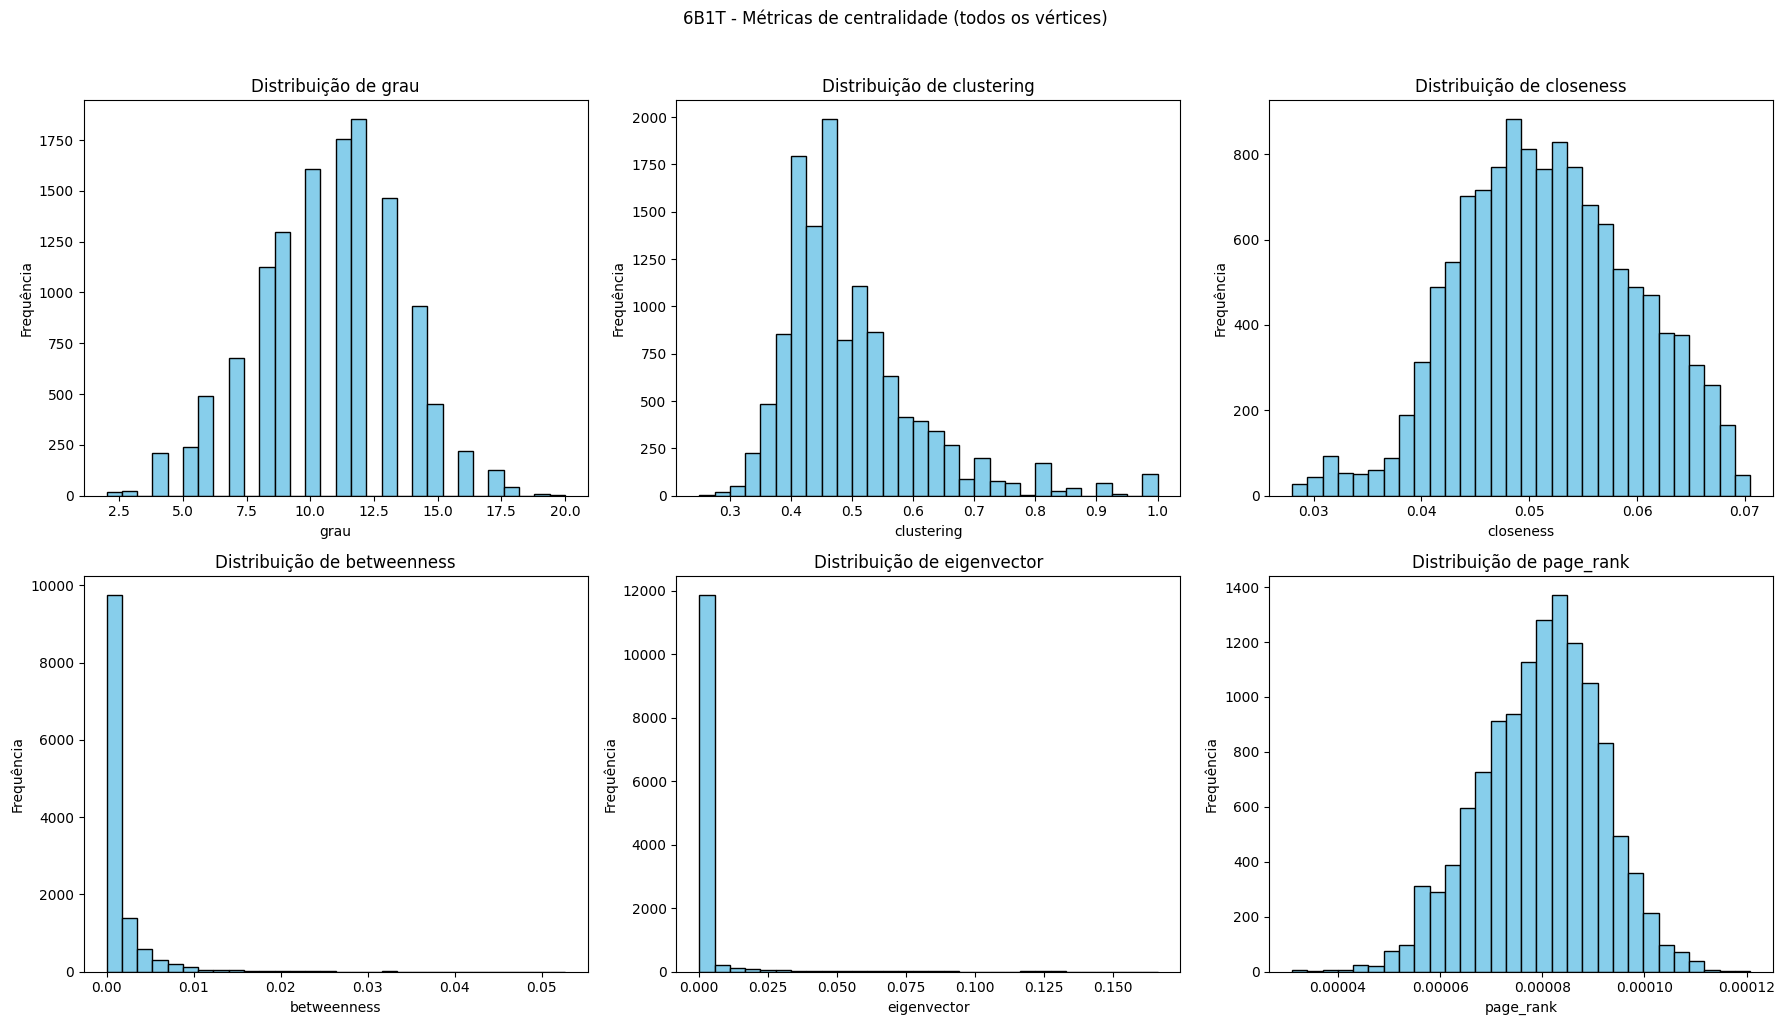

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    axes[i].hist(df_nos[metric], bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
plt.suptitle(nome_proteina+" - Métricas de centralidade (todos os vértices)", y=1.02)
plt.tight_layout()
plt.show()

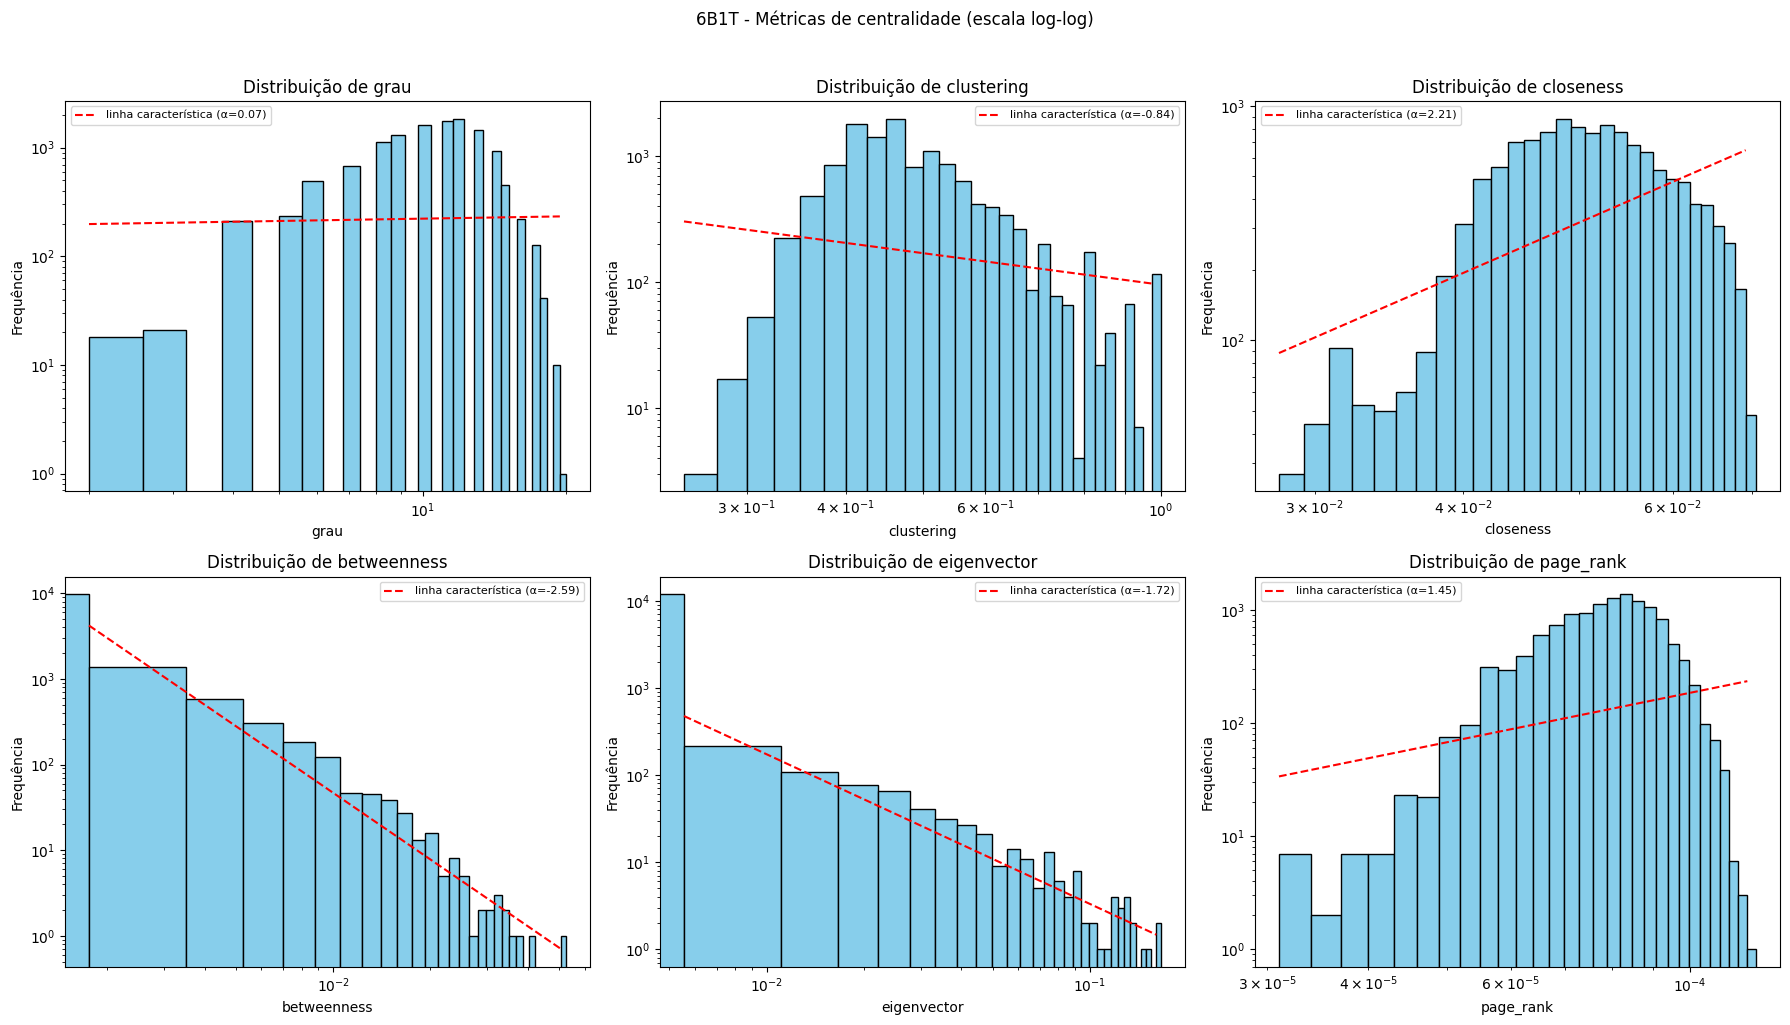

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # grid 2x3
axes = axes.flatten()

for i, metric in enumerate(metricas):
    valores = df_nos[metric]
    
    # Histograma
    counts, bins, _ = axes[i].hist(valores, bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuição de {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frequência")
    
    # Escala log-log
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    
    # Linha característica (ajuste linear em log-log)
    mask = (counts > 0) & (bins[:-1] > 0)  # filtrar valores válidos
    x = bins[:-1][mask]
    y = counts[mask]
    
    if len(x) > 2:  # só ajusta se houver pontos suficientes
        logx = np.log10(x)
        logy = np.log10(y)
        
        try:
            coef = np.polyfit(logx, logy, 1)  # ajuste linear em log-log
            fitted = 10**(coef[1]) * x**coef[0]
            axes[i].plot(x, fitted, "r--", label=f"linha característica (α={coef[0]:.2f})")
            axes[i].legend(fontsize=8)
        except np.linalg.LinAlgError:
            # Se o ajuste não convergir, apenas pula
            pass


plt.suptitle(nome_proteina+" - Métricas de centralidade (escala log-log)", y=1.02)
plt.tight_layout()
plt.show()


,grau,clustering,closeness,betweenness,eigenvector,page_rank
grau,1.00,-0.69,0.19,0.22,0.16,0.85
clustering,-0.69,1.00,-0.22,-0.25,-0.08,-0.61
closeness,0.19,-0.22,1.00,0.40,-0.16,0.05
betweenness,0.22,-0.25,0.40,1.00,-0.04,0.14
eigenvector,0.16,-0.08,-0.16,-0.04,1.00,0.08
page_rank,0.85,-0.61,0.05,0.14,0.08,1.00


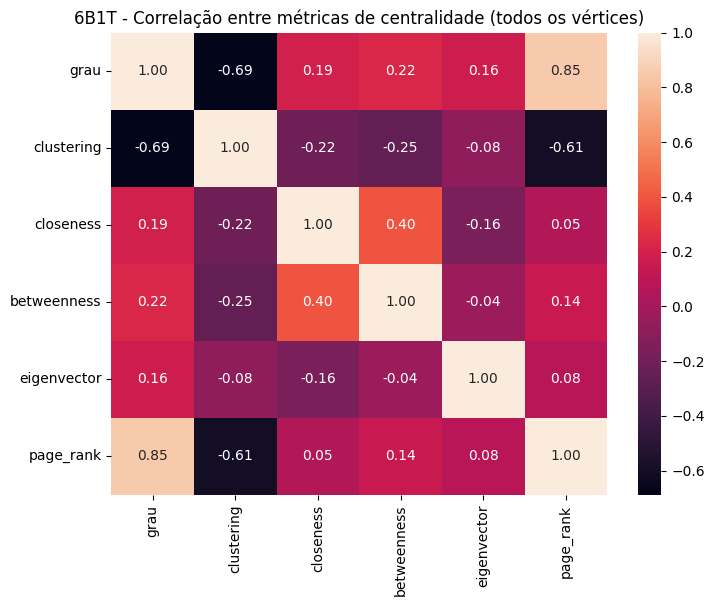

In [29]:
# Matriz de correlação entre todas as métricas
corr = df_nos[metricas].corr()
display(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title(nome_proteina+" - Correlação entre métricas de centralidade (todos os vértices)")
plt.show()



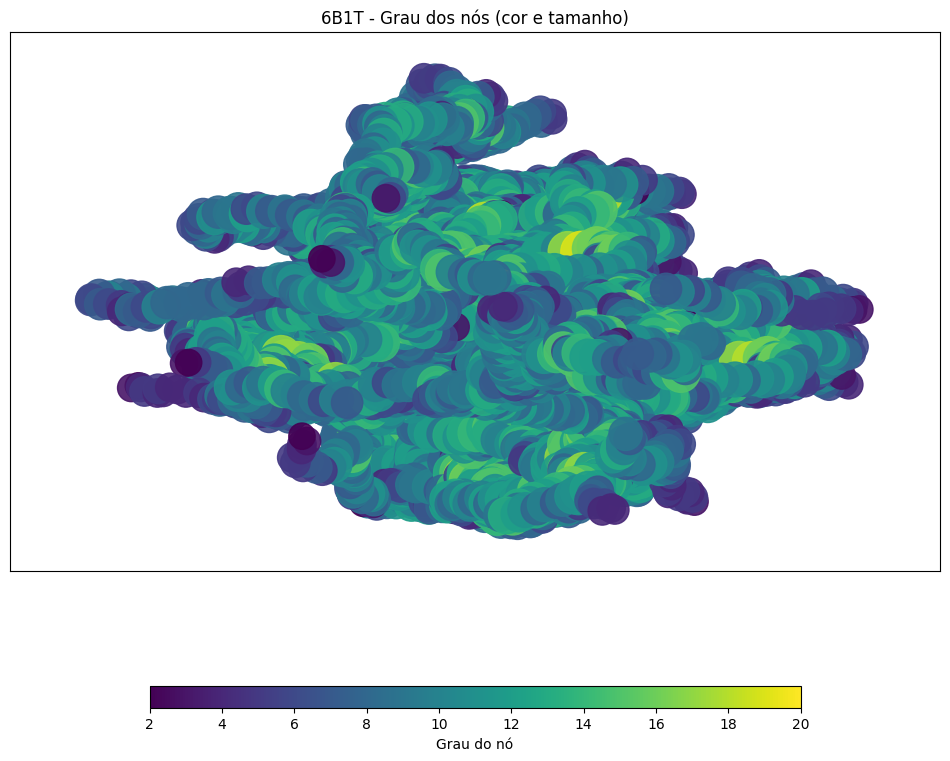

In [49]:
graus = df_nos["grau"]

# Normalização dos valores de grau
norm = plt.Normalize(vmin=graus.min(), vmax=graus.max())

# Cores baseadas no grau
cores = plt.cm.viridis(norm(graus))

# Tamanho proporcional ao grau
node_sizes = [300 + g*30 for g in graus] 

# Criar dicionário de posições para o layout
pos = {}
for _, linha in df_residuos.iterrows():
    pos[linha["node_id"]] = (
        linha["x"],
        linha["y"]
    )

plt.figure(figsize=(12,10))
ax = plt.gca()

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=ax
)

plt.title(nome_proteina + " - Grau dos nós (cor e tamanho)")

# Barra de cores para interpretação
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ax=ax,
    label="Grau do nó",
    shrink=0.7,
    aspect=30,
    orientation="horizontal"
)

plt.show()


C:\Users\amaur\AppData\Local\Temp\ipykernel_14932\971421356.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


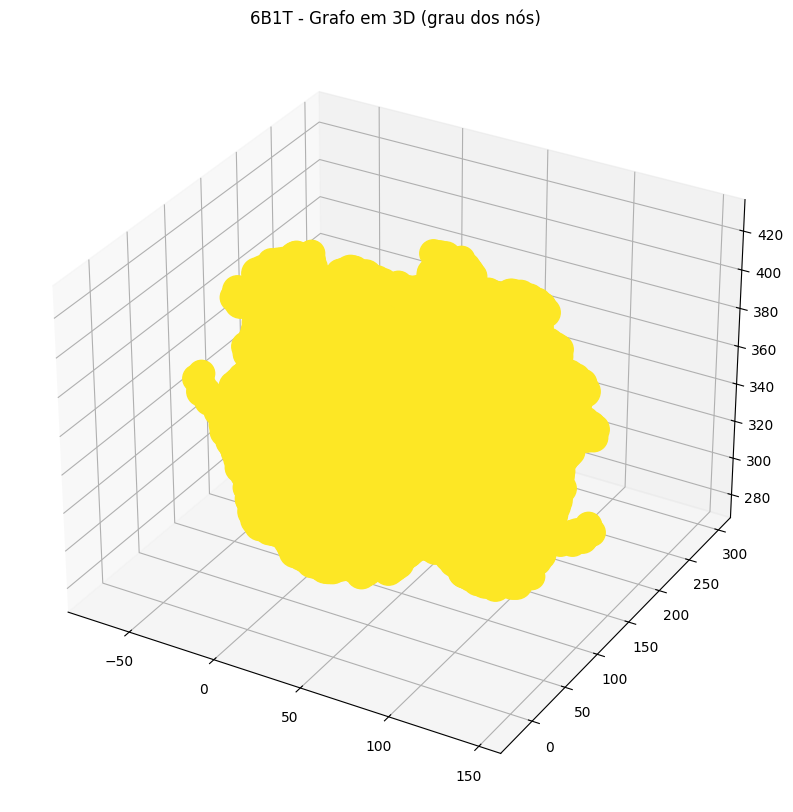

In [56]:
df_plot = df_residuos.merge(df_nos, on="node_id")

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection="3d")

for _, linha in df_plot.iterrows():
    ax.scatter(
        linha["x"], linha["y"], linha["z"],
        s=300 + linha["grau"]*30,
        c=plt.cm.viridis(norm(linha["grau"]))
    )

plt.title(nome_proteina + " - Grafo em 3D (grau dos nós)")
plt.show()


In [57]:
df_plot.head()

,arquivo,cadeia,residuo_id,residuo_nome,x,y,z,node_id,comunidade_louvain,comunidade_infomap,grau,clustering,closeness,betweenness,eigenvector,page_rank
0,6b1t-pdb-bundle1.pdb,A,6,MET,35.067001,140.119003,314.084015,A_6,6,0,6,0.733333,0.061136,7.734078e-05,1.325660e-11,0.000051
1,6b1t-pdb-bundle1.pdb,A,7,MET,32.890999,138.360001,316.661987,A_7,6,0,5,0.900000,0.060375,4.403346e-07,1.172895e-11,0.000056
2,6b1t-pdb-bundle1.pdb,A,8,PRO,29.086000,138.692993,316.332001,A_8,6,0,9,0.416667,0.062530,4.313725e-03,5.285468e-11,0.000078
3,6b1t-pdb-bundle1.pdb,A,9,GLN,28.686001,139.419006,320.045013,A_9,6,0,7,0.571429,0.062270,6.512262e-04,3.477341e-11,0.000067
4,6b1t-pdb-bundle1.pdb,A,10,TRP,31.304001,142.171997,320.027008,A_10,6,0,11,0.581818,0.062291,3.751110e-04,2.598822e-11,0.000094


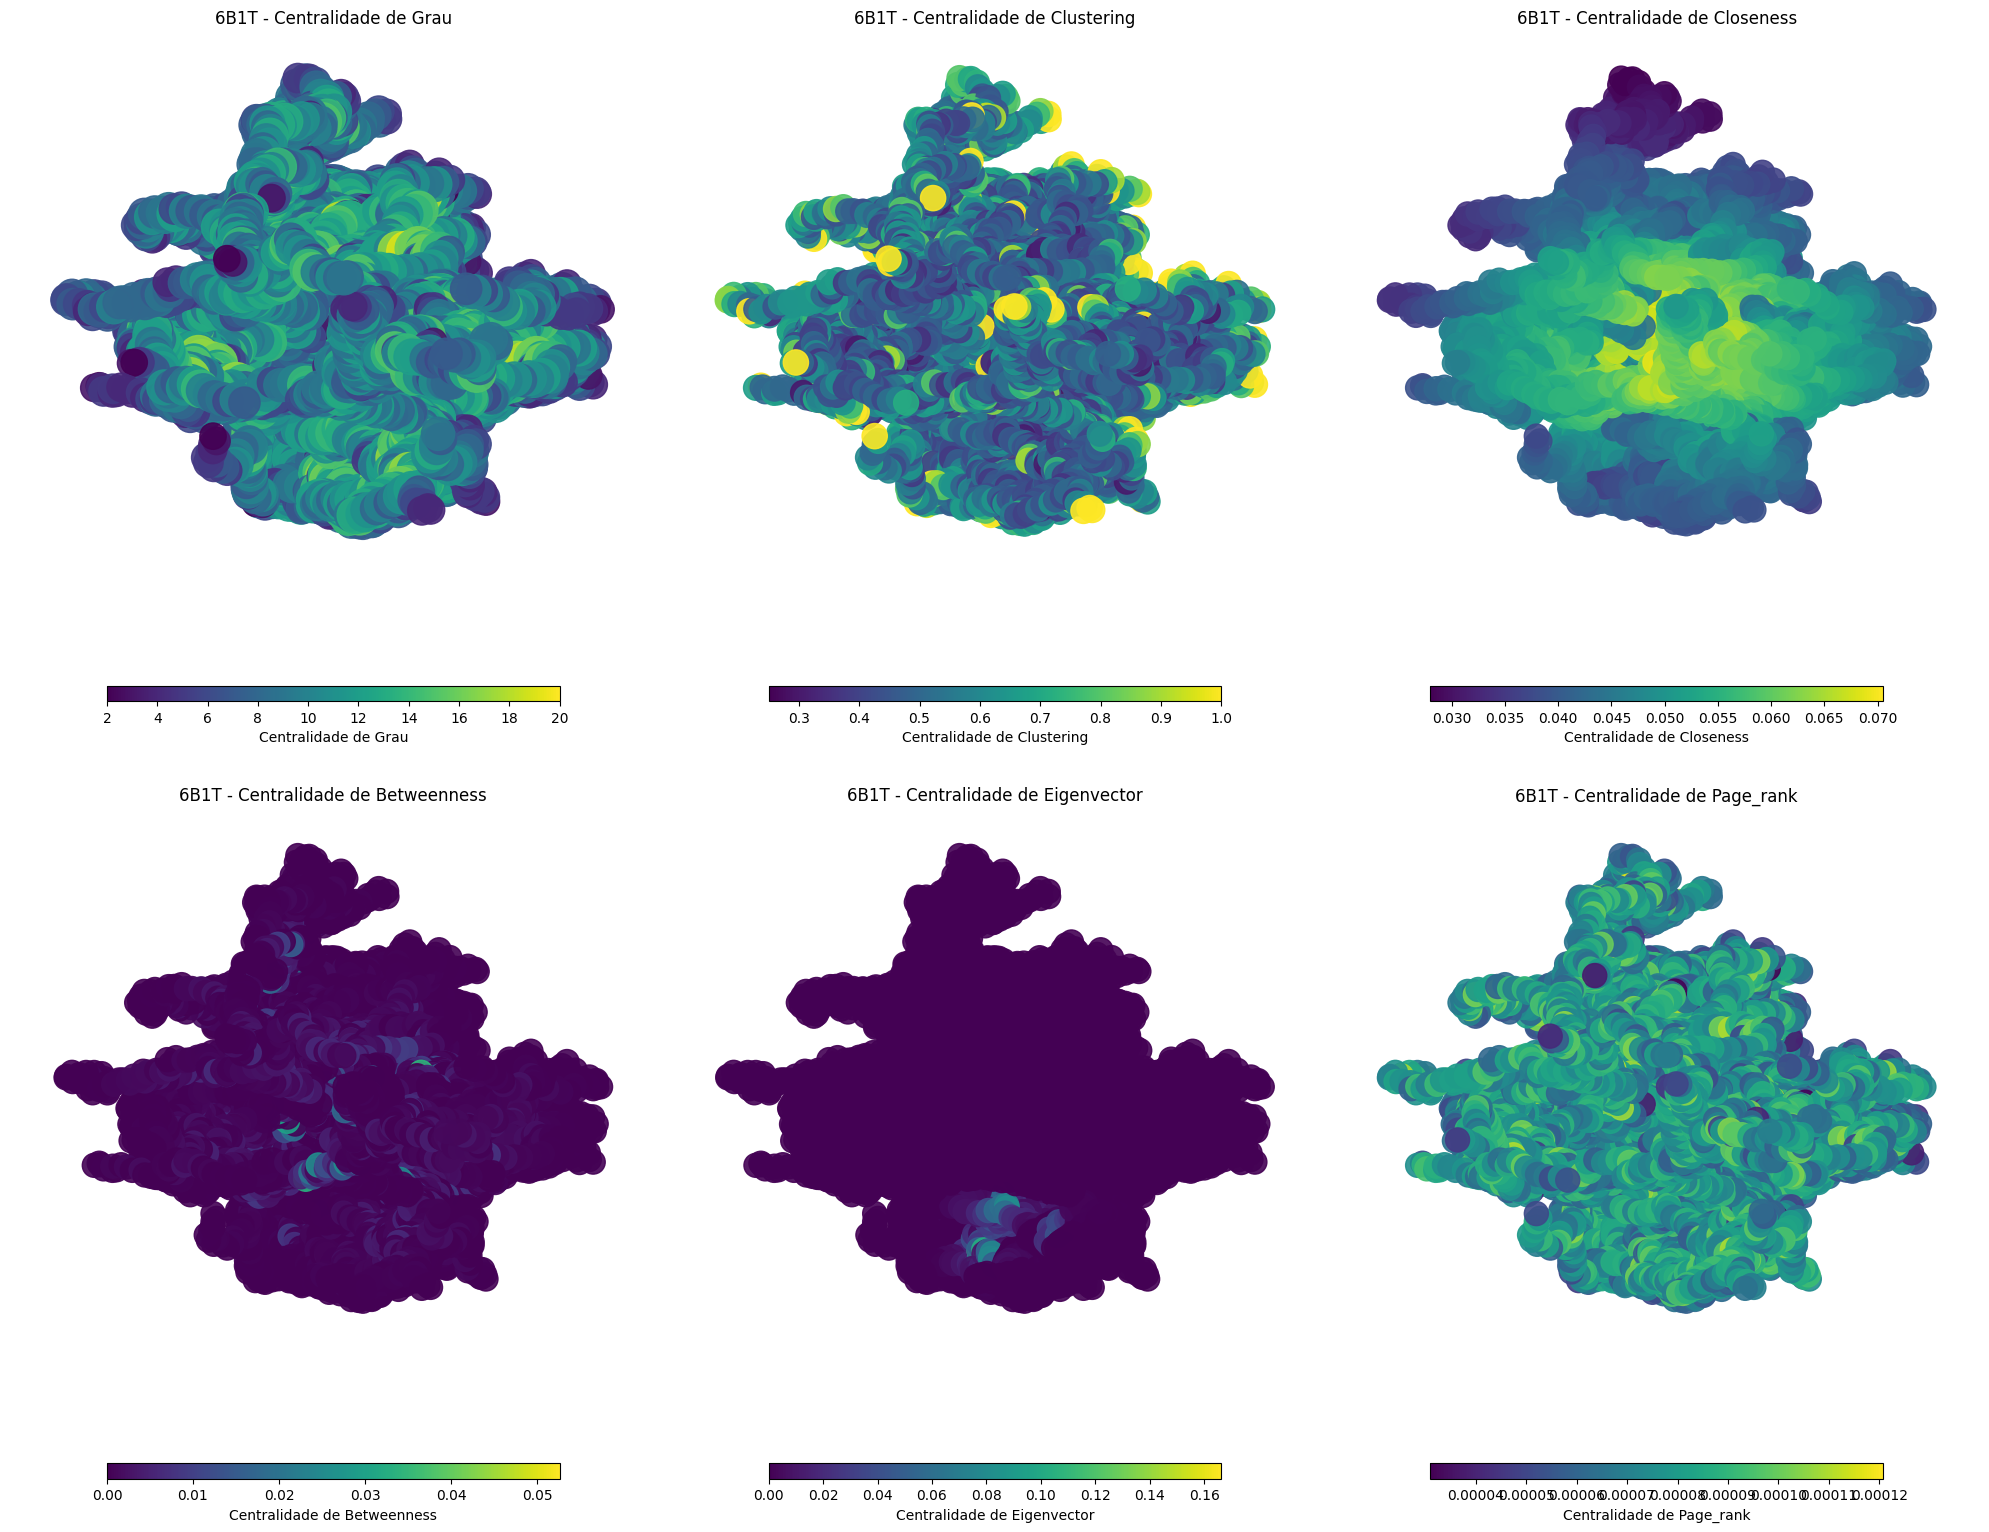

In [50]:
# Paleta de cores contínua
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 3, figsize=(20,16))  # 2x3 grid
axes = axes.flatten()

for i, metric in enumerate(metricas):
    valores = df_nos[metric]
    
    # Normalização para colormap
    norm = plt.Normalize(vmin=valores.min(), vmax=valores.max())
    cores = cmap(norm(valores))
    
    # Tamanho proporcional ao valor da métrica
    node_sizes = [300 + v*30 for v in valores]
    
    nx.draw_networkx(
        G,
        pos=pos,
        node_size=node_sizes,
        node_color=cores,
        with_labels=False,
        font_size=7,
        edge_color="lightgray",
        alpha=0.9,
        ax=axes[i]
    )
    
    axes[i].set_title(nome_proteina + f" - Centralidade de {metric.capitalize()}")
    axes[i].axis("off")
    
    # Barra de cores para interpretação
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(
        sm,
        ax=axes[i],
        label=f"Centralidade de {metric.capitalize()}",
        shrink=0.7,
        aspect=30,
        orientation="horizontal"
    )

plt.tight_layout()
plt.show()


Autovalores:
[0.0000e+00 9.0000e-04 1.8000e-03 ... 3.6689e+00 3.6978e+00 3.7822e+00]


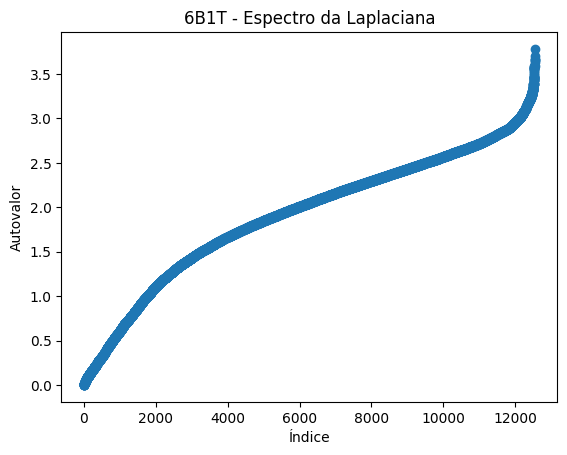

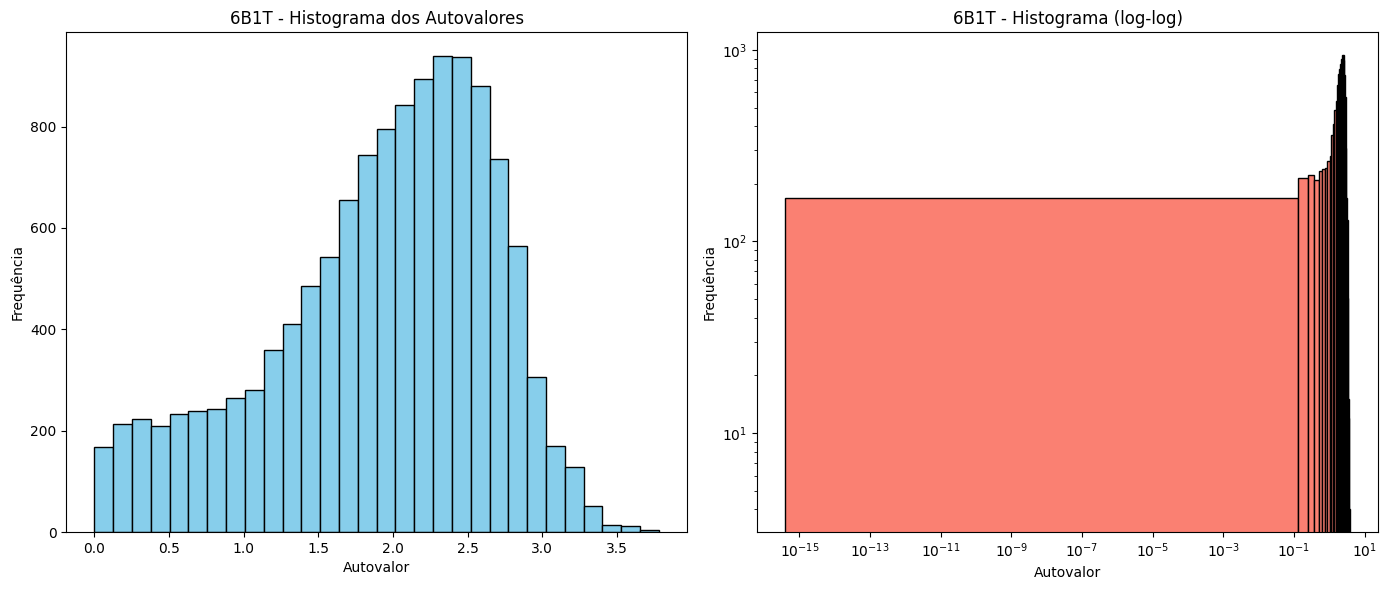

In [ ]:
# Matriz de adjacência e Laplaciana
A = nx.to_numpy_array(G)
D = np.diag(np.sum(A, axis=1))
L = D - A

# Autovalores e autovetores
eigvals, eigvecs = np.linalg.eig(L)

print("Autovalores:")
print(np.sort(np.round(eigvals,4))) # Autovalores ordenados e arredondados



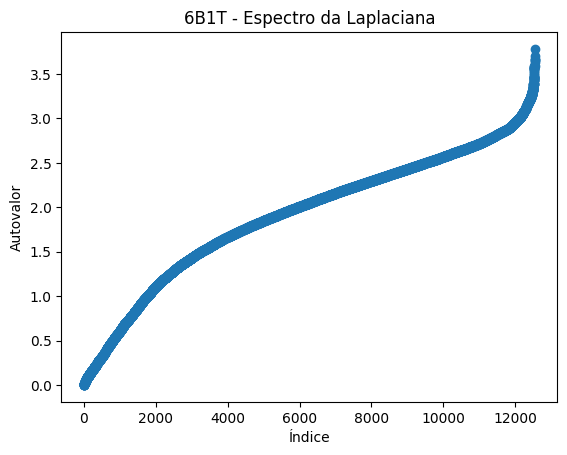

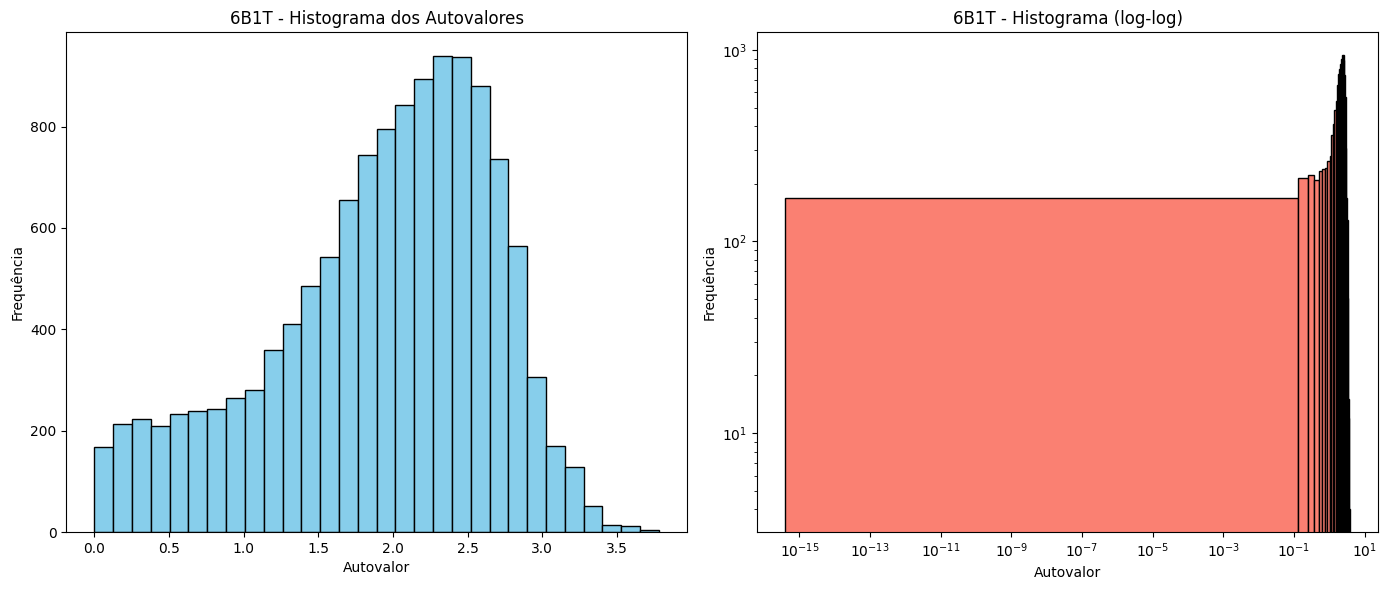

In [34]:
# Espectro da Laplaciana
plt.plot(sorted(eigvals), 'o-')
plt.title(nome_proteina + " - Espectro da Laplaciana")
plt.xlabel("Índice")
plt.ylabel("Autovalor")
plt.show()

# Subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Histograma dos Autovalores ---
axes[0].hist(eigvals, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title(nome_proteina + " - Histograma dos Autovalores")
axes[0].set_xlabel("Autovalor")
axes[0].set_ylabel("Frequência")

# --- Histograma dos Autovalores em escala log-log ---
axes[1].hist(eigvals, bins=30, color="salmon", edgecolor="black")
axes[1].set_title(nome_proteina + " - Histograma (log-log)")
axes[1].set_xlabel("Autovalor")
axes[1].set_ylabel("Frequência")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


Vetor de Fiedler:
[-0.0062 -0.006  -0.0057 ... -0.007  -0.0068 -0.0067]


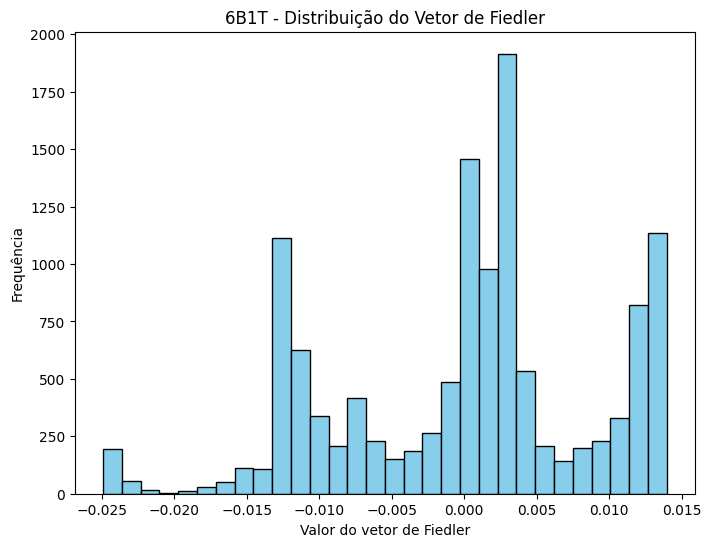

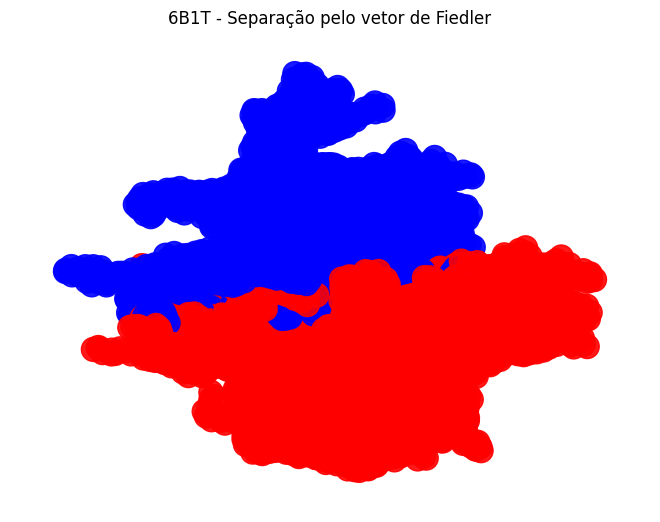

In [36]:
idx = np.argsort(eigvals) # Índices dos autovalores ordenados
fiedler = eigvecs[:, idx[1]]

print("Vetor de Fiedler:")
print(np.round(fiedler,4))
# O vetor de Fiedler é o autovetor correspondente ao segundo menor autovalor da matriz laplaciana.
# Ele é usado para identificar a estrutura do grafo, como a presença de comunidades ou a conectividade entre os nós.
# Nós com valores semelhantes no vetor de Fiedler tendem a estar mais fortemente conectados entre si, enquanto nós com valores diferentes tendem a estar menos conectados.

# Histograma da distribuição dos valores do vetor de Fiedler
plt.figure(figsize=(8,6))
plt.hist(fiedler, bins=30, color="skyblue", edgecolor="black")
plt.title(nome_proteina + " - Distribuição do Vetor de Fiedler")
plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")
plt.show()


colors = ['red' if v>0 else 'blue' for v in fiedler]
nx.draw(G,
        pos=pos,
        node_size=node_sizes,
        node_color=colors,
        with_labels=False,
        font_size=7,
        edge_color="lightgray",
        alpha=0.9,
        )
plt.title(nome_proteina + " - Separação pelo vetor de Fiedler")
plt.show()

In [37]:
# ============================================================
# DETECÇÃO DE COMUNIDADES - louvain_communities
# ============================================================

comunidades_louvain = louvain_communities(G)
print("Quantidade de comunidades Louvain:", len(comunidades_louvain))
for i, c in enumerate(comunidades_louvain):
    print(f'Comunidade {i}: {len(c)} nós')

# Criar dicionário: node_id -> comunidade
map_comunidades_louvain = {}
for i, c in enumerate(comunidades_louvain):
    for node in c:
        map_comunidades_louvain[node] = i

# Usar o dicionário no map
df_residuos["comunidade_louvain"] = df_residuos["node_id"].map(map_comunidades_louvain)

# ============================================================
# MODULARIDADE
# ============================================================
Q_nx = modularity(G, comunidades_louvain)
print(f'Modularidade Louvain NetworkX: {Q_nx:.4f}')

df_residuos.head()

Quantidade de comunidades Louvain: 35
Comunidade 0: 316 nós
Comunidade 1: 649 nós
Comunidade 2: 546 nós
Comunidade 3: 251 nós
Comunidade 4: 336 nós
Comunidade 5: 242 nós
Comunidade 6: 461 nós
Comunidade 7: 535 nós
Comunidade 8: 332 nós
Comunidade 9: 538 nós
Comunidade 10: 520 nós
Comunidade 11: 288 nós
Comunidade 12: 316 nós
Comunidade 13: 266 nós
Comunidade 14: 199 nós
Comunidade 15: 328 nós
Comunidade 16: 664 nós
Comunidade 17: 506 nós
Comunidade 18: 423 nós
Comunidade 19: 321 nós
Comunidade 20: 480 nós
Comunidade 21: 246 nós
Comunidade 22: 501 nós
Comunidade 23: 530 nós
Comunidade 24: 475 nós
Comunidade 25: 356 nós
Comunidade 26: 270 nós
Comunidade 27: 165 nós
Comunidade 28: 137 nós
Comunidade 29: 162 nós
Comunidade 30: 47 nós
Comunidade 31: 568 nós
Comunidade 32: 36 nós
Comunidade 33: 403 nós
Comunidade 34: 131 nós
Modularidade Louvain NetworkX: 0.9051


,arquivo,cadeia,residuo_id,residuo_nome,x,y,z,node_id,comunidade_louvain
0,6b1t-pdb-bundle1.pdb,A,6,MET,35.067001,140.119003,314.084015,A_6,6
1,6b1t-pdb-bundle1.pdb,A,7,MET,32.890999,138.360001,316.661987,A_7,6
2,6b1t-pdb-bundle1.pdb,A,8,PRO,29.086000,138.692993,316.332001,A_8,6
3,6b1t-pdb-bundle1.pdb,A,9,GLN,28.686001,139.419006,320.045013,A_9,6
4,6b1t-pdb-bundle1.pdb,A,10,TRP,31.304001,142.171997,320.027008,A_10,6


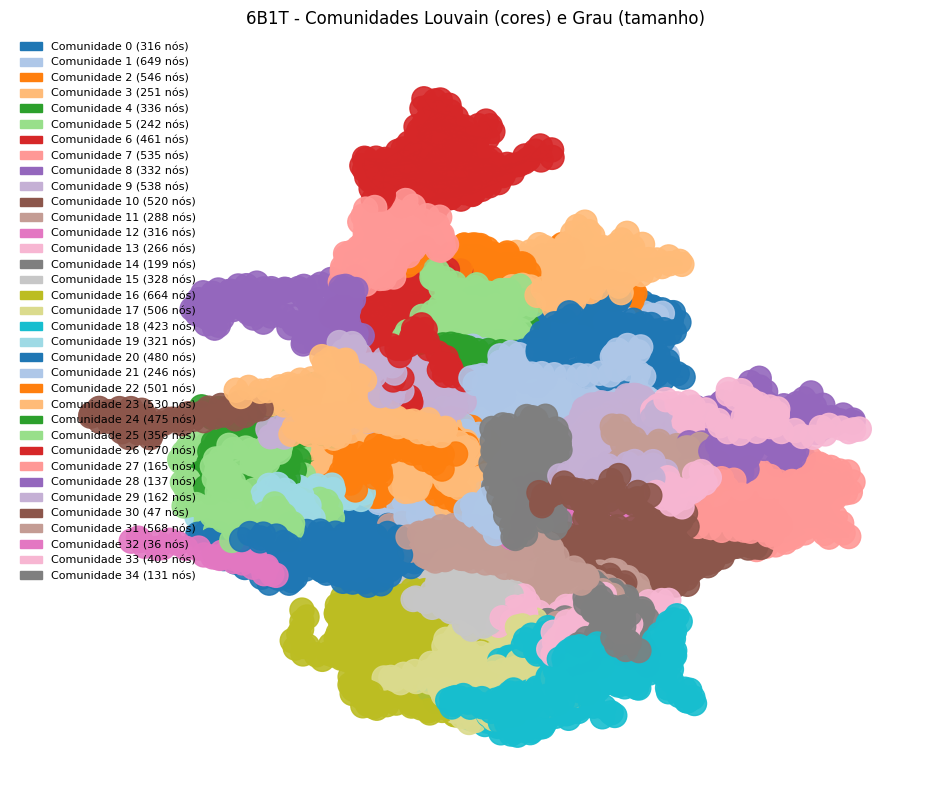

In [38]:
# Graus diretamente do grafo
graus_dict = dict(G.degree())

# Comunidade de cada nó (já mapeada)
comunidades_louvain_nos = [map_comunidades_louvain[n] for n in G.nodes()]

# Paleta de cores categóricas
cmap = plt.cm.tab20
cores = [cmap(i % 20) for i in comunidades_louvain_nos]

plt.figure(figsize=(12,10))
ax = plt.gca()

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=ax
)

plt.title(nome_proteina + " - Comunidades Louvain (cores) e Grau (tamanho)")
plt.axis("off")

# Criar legenda categórica com cores corretas
legenda = []
for i, comunidade in enumerate(comunidades_louvain):
    cor = cmap(i % 20)
    legenda.append(Patch(color=cor, label=f"Comunidade {i} ({len(comunidade)} nós)"))

plt.legend(handles=legenda, loc="best", fontsize=8, frameon=False)

plt.show()


In [42]:
# ============================================================
# DETECÇÃO DE COMUNIDADES - Infomap
# ============================================================

# Criar mapeamento node_id -> inteiro e inverso
node_to_int = {node: i for i, node in enumerate(G.nodes())}
int_to_node = {i: node for node, i in node_to_int.items()}

im = Infomap()

# Adicionar arestas com IDs inteiros
for u, v in G.edges():
    im.add_link(node_to_int[u], node_to_int[v])

im.run()

# Extrair comunidades como conjuntos de nomes originais
comunidades_infomap = {}
for node in im.nodes:
    comunidades_infomap.setdefault(node.module_id, set()).add(int_to_node[node.node_id])

# Converter para lista de conjuntos
comunidades_infomap = list(comunidades_infomap.values())

# Criar dicionário node_id -> comunidade
map_comunidades_infomap = {}
for i, c in enumerate(comunidades_infomap):
    for node_name in c:
        map_comunidades_infomap[node_name] = i

# Adicionar ao dataframe
df_residuos["comunidade_infomap"] = df_residuos["node_id"].map(map_comunidades_infomap)

# Modularidade
from networkx.algorithms.community import modularity
Q_im = modularity(G, comunidades_infomap)
print(f"Modularidade Infomap: {Q_im:.4f}")


# Impressão no mesmo padrão do Louvain
print("Quantidade de comunidades Infomap:", len(comunidades_infomap))
for i, c in enumerate(comunidades_infomap):
    print(f"Comunidade {i}: {len(c)} nós")


df_residuos.head()


Modularidade Infomap: 0.7325
Quantidade de comunidades Infomap: 4
Comunidade 0: 4140 nós
Comunidade 1: 2952 nós
Comunidade 2: 2902 nós
Comunidade 3: 2550 nós


,arquivo,cadeia,residuo_id,residuo_nome,x,y,z,node_id,comunidade_louvain,comunidade_infomap
0,6b1t-pdb-bundle1.pdb,A,6,MET,35.067001,140.119003,314.084015,A_6,6,0
1,6b1t-pdb-bundle1.pdb,A,7,MET,32.890999,138.360001,316.661987,A_7,6,0
2,6b1t-pdb-bundle1.pdb,A,8,PRO,29.086000,138.692993,316.332001,A_8,6,0
3,6b1t-pdb-bundle1.pdb,A,9,GLN,28.686001,139.419006,320.045013,A_9,6,0
4,6b1t-pdb-bundle1.pdb,A,10,TRP,31.304001,142.171997,320.027008,A_10,6,0


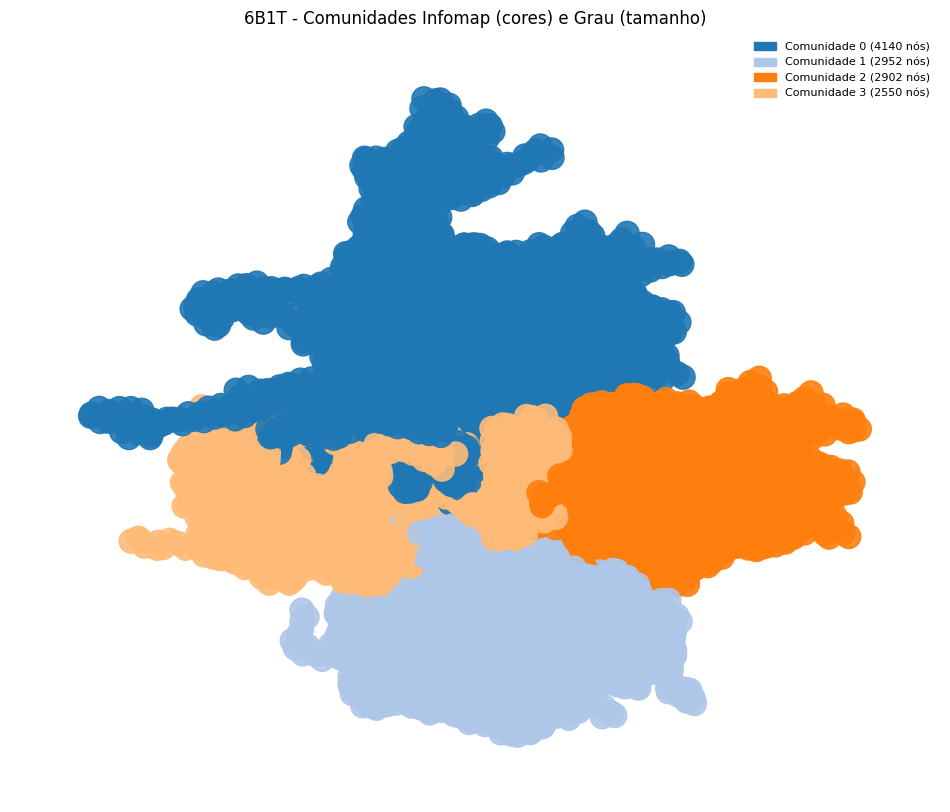

In [43]:
# ============================================================
# VISUALIZAÇÃO DAS COMUNIDADES - Infomap
# ============================================================

# Graus diretamente do grafo
graus_dict = dict(G.degree())

# Comunidade de cada nó (já mapeada)
comunidades_infomap_nos = [map_comunidades_infomap[n] for n in G.nodes()]

# Paleta de cores categóricas
cmap = plt.cm.tab20
cores = [cmap(i % 20) for i in comunidades_infomap_nos]

plt.figure(figsize=(12,10))
ax = plt.gca()

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=ax
)

plt.title(nome_proteina + " - Comunidades Infomap (cores) e Grau (tamanho)")
plt.axis("off")

# Criar legenda categórica com cores corretas
legenda = []
for i, comunidade in enumerate(comunidades_infomap):
    cor = cmap(i % 20)
    legenda.append(Patch(color=cor, label=f"Comunidade {i} ({len(comunidade)} nós)"))

plt.legend(handles=legenda, loc="best", fontsize=8, frameon=False)

plt.show()


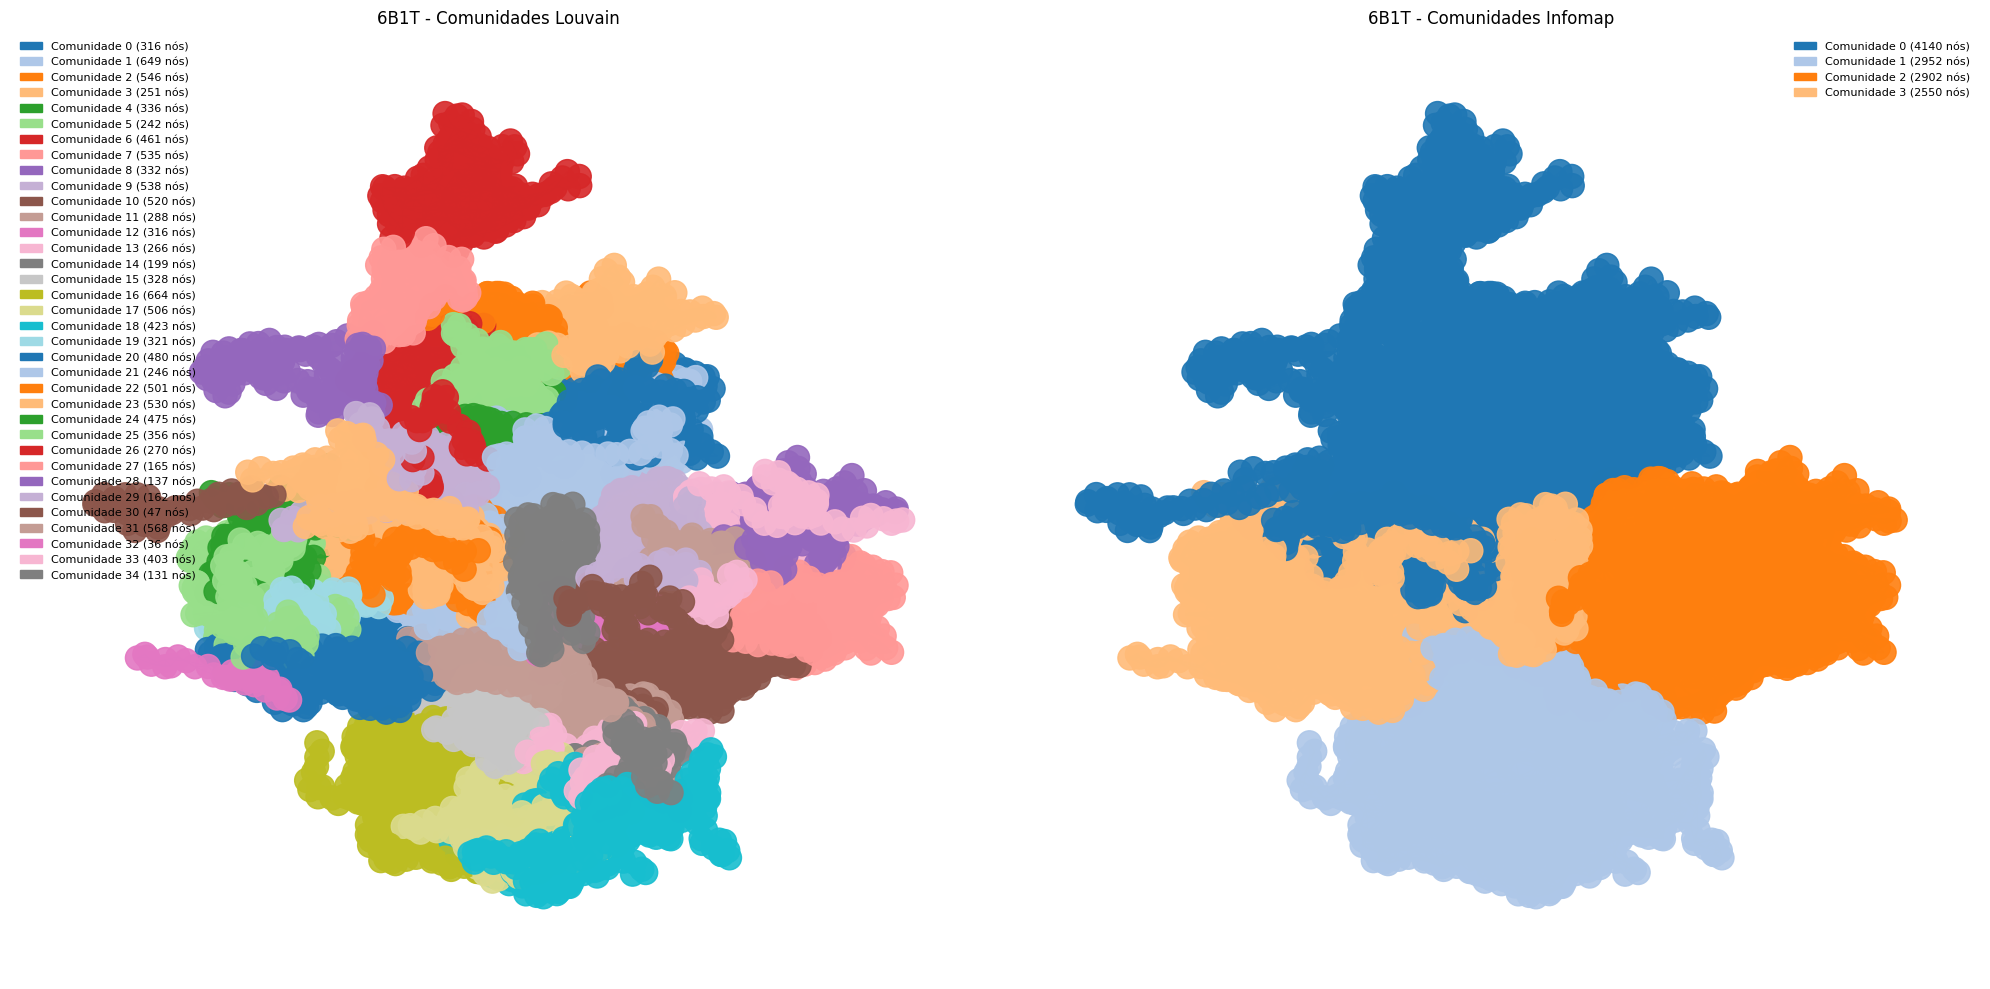

In [45]:
# Graus diretamente do grafo
graus_dict = dict(G.degree())

# Comunidade Louvain
comunidades_nos_louvain = [map_comunidades_louvain[n] for n in G.nodes()]

# Comunidade Infomap
comunidades_nos_infomap = [map_comunidades_infomap[n] for n in G.nodes()]

# Paleta de cores categóricas
cmap = plt.cm.tab20

fig, axes = plt.subplots(1, 2, figsize=(20,10))

# --- Gráfico Louvain ---
cores_louvain = [cmap(i % 20) for i in comunidades_nos_louvain]
nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores_louvain,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=axes[0]
)
axes[0].set_title(nome_proteina + " - Comunidades Louvain")
axes[0].axis("off")

# Legenda Louvain
legenda_louvain = []
for i, comunidade in enumerate(comunidades_louvain):
    legenda_louvain.append(Patch(color=cmap(i % 20), label=f"Comunidade {i} ({len(comunidade)} nós)"))
axes[0].legend(handles=legenda_louvain, fontsize=8, frameon=False)

# --- Gráfico Infomap ---
cores_infomap = [cmap(i % 20) for i in comunidades_nos_infomap]
nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color=cores_infomap,
    with_labels=False,
    font_size=7,
    edge_color="lightgray",
    alpha=0.9,
    ax=axes[1]
)
axes[1].set_title(nome_proteina + " - Comunidades Infomap")
axes[1].axis("off")

# Legenda Infomap
legenda_infomap = []
for i, comunidade in enumerate(comunidades_infomap):
    legenda_infomap.append(Patch(color=cmap(i % 20), label=f"Comunidade {i} ({len(comunidade)} nós)"))
axes[1].legend(handles=legenda_infomap, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
# Gerar matriz de adjacência como DataFrame
adj_matrix = nx.to_pandas_adjacency(G)

# Exportar para CSV
adj_matrix.to_csv("data/output/"+nome_proteina+ "_matriz_adjacencia.csv", index=True)
df_residuos.to_csv("data/output/"+nome_proteina+ "_residuos.csv", index=True)
df_nos.to_csv("data/output/"+nome_proteina+ "_nos.csv", index=True)
df_plot.to_csv("data/output/"+nome_proteina+ "_estats.csv", index=True)
